# Early Sepsis Risk Prediction — Feature Engineering
## Section 5: Feature Engineering
**Author:** Varunika Bussa  
**Course:** UMBC DATA 606 – Capstone in Data Science  
**Dataset:** PhysioNet 2019 Sepsis Challenge Dataset  

---

## Why Feature Engineering?

From our EDA we learned three critical things:
1. **No single vital sign strongly predicts sepsis** — the highest correlation with SepsisLabel was only 0.13
2. **Trends matter more than snapshots** — Patient 18469's Respiratory Rate rose slowly for 200+ hours before sepsis onset
3. **Missingness is a signal** — labs are only ordered when clinicians suspect a problem (MNAR)

Raw features like "HR = 95 at hour 10" tell us very little. But "HR has been rising by 2 bpm per hour over the last 6 hours" is clinically meaningful.

Feature engineering transforms our raw time-series data into a rich set of predictive signals that capture:
- **What is happening right now** (raw values)
- **What has been happening recently** (rolling window statistics)
- **Which direction things are moving** (trend/slope features)
- **Whether labs were actually measured** (missingness flags)
- **Clinically derived risk indicators** (SOFA-inspired features)

---

### Input: `../Dataset.csv` — 1,552,210 rows × 43 columns (raw ICU data)
### Output: `../outputs/features.parquet` — enriched feature set ready for modeling

## 1. Setup and Data Loading

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

print('✅ All libraries loaded successfully!')
print(f'   pandas  version: {pd.__version__}')
print(f'   numpy   version: {np.__version__}')

✅ All libraries loaded successfully!
   pandas  version: 2.3.3
   numpy   version: 2.0.2


In [3]:
# Load the raw dataset — same as EDA
# index_col=0 drops the unnamed row-number column
df = pd.read_csv('../Dataset.csv', index_col=0)

print(f'Raw dataset shape: {df.shape}')
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'Unique patients: {df["Patient_ID"].nunique():,}')
df.head(3)

Raw dataset shape: (1552210, 43)
Rows:    1,552,210
Columns: 43
Unique patients: 40,336


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.540,0,NaN,NaN,-0.020,1,0,17072
1,1,65.000,100.000,NaN,NaN,72.000,NaN,16.500,NaN,NaN,NaN,0.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.540,0,NaN,NaN,-0.020,2,0,17072
2,2,78.000,100.000,NaN,NaN,42.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.540,0,NaN,NaN,-0.020,3,0,17072


## 2. Feature Group Definitions

Before we engineer features, we organize columns into logical groups.
This is identical to our EDA setup — we carry these definitions forward
so feature engineering is consistent with our analysis.

In [4]:
# Feature group definitions (consistent with EDA notebook)
VITALS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

LABS = [
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
    'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
    'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
    'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb',
    'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'EtCO2'
]

DEMOGRAPHICS = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime']

# Features to drop — >96% missing, too sparse to be useful
DROP_FEATURES = ['EtCO2', 'Fibrinogen', 'Bilirubin_direct']

# Labs to forward-fill (27 total - 3 dropped = 24)
FFILL_LABS = [c for c in LABS if c not in DROP_FEATURES]

# Key vitals and labs we will create trend features for
TREND_FEATURES = ['HR', 'MAP', 'Resp', 'O2Sat', 'Temp', 'Lactate', 'WBC', 'Creatinine', 'pH']

print(f'Vitals:          {len(VITALS)} features — {VITALS}')
print(f'Labs to ffill:   {len(FFILL_LABS)} features')
print(f'Labs to drop:    {DROP_FEATURES}')
print(f'Trend features:  {len(TREND_FEATURES)} — {TREND_FEATURES}')

Vitals:          7 features — ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
Labs to ffill:   24 features
Labs to drop:    ['EtCO2', 'Fibrinogen', 'Bilirubin_direct']
Trend features:  9 — ['HR', 'MAP', 'Resp', 'O2Sat', 'Temp', 'Lactate', 'WBC', 'Creatinine', 'pH']


## 3. Step 1 — Drop Sparse Features and Clean

**Why drop EtCO2, Fibrinogen, Bilirubin_direct?**

From our EDA, these three features had >96% missing values:
- EtCO2: 96.3% missing
- Fibrinogen: 99.3% missing  
- Bilirubin_direct: 99.8% missing

With so little data, forward-filling would mean carrying a single reading 
forward for potentially hundreds of hours — that is fabricated data, not 
a real measurement. Dropping them is the honest choice.

**Why fill Unit1/Unit2 NaN with 0?**

Unit1 and Unit2 are binary flags (0 or 1) indicating ICU type. 
A missing value here simply means the unit type wasn't recorded, 
which we treat as "not in that unit type" = 0.

In [6]:
# Drop sparse features 
df = df.drop(columns=DROP_FEATURES, errors='ignore')

# Fill Unit1/Unit2 NaN with 0 (binary flags)
df['Unit1'] = df['Unit1'].fillna(0)
df['Unit2'] = df['Unit2'].fillna(0)

print(f'Shape after dropping sparse features: {df.shape}')
print(f'Dropped: {DROP_FEATURES}')
print(f'\nRemaining columns ({df.shape[1]}):')
print(list(df.columns))

Shape after dropping sparse features: (1552210, 40)
Dropped: ['EtCO2', 'Fibrinogen', 'Bilirubin_direct']

Remaining columns (40):
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


## 3. Train / Validation / Test Split (BY PATIENT)

**This is the most important step — and it must happen BEFORE any feature engineering.**

### Why split before feature engineering?

If we forward-fill or compute rolling statistics on the full dataset and THEN split,
the model has already "seen" test patients during feature construction. This is **data leakage**.

Even though our specific operations (forward-fill, rolling windows, slopes) are 
per-patient and row-level — meaning they don't directly leak across patients — 
establishing the split first is the **correct professional practice** because:

1. It makes the pipeline future-proof — if we add mean imputation or scaling later, the split is already in place
2. It documents a clear, auditable boundary between train and test data
3. It prevents any accidental cross-patient feature that could sneak in

### Why split by Patient_ID, not by rows?

This is **critical**. If we split randomly by rows, the same patient could appear in 
both train and test sets. The model would then be evaluated on patients it has 
already learned from — badly inflating performance metrics.

**Wrong split (data leakage):**
```
Row 1:  Patient_001, Hour 1  → Train
Row 2:  Patient_001, Hour 2  → Test   ← same patient in both!
```

**Correct split (patient-level):**
```
Patient_001 → ALL their rows go to Train
Patient_002 → ALL their rows go to Test
```

### Split ratio: 70 / 15 / 15

- **Train (70%)** — model learns patterns from these patients
- **Validation (15%)** — tune hyperparameters, select threshold
- **Test (15%)** — final unbiased evaluation, reported in paper

### Stratified by sepsis status

We use stratified splitting to ensure sepsis patients (7.27%) are proportionally 
represented in all three splits. Without stratification, we might accidentally 
put most sepsis patients in train and have very few in test.

In [7]:
from sklearn.model_selection import train_test_split

# Get one row per patient with their sepsis label
# We need patient-level labels for stratified splitting
patient_labels = df.groupby('Patient_ID')['SepsisLabel'].max().reset_index()
patient_labels.columns = ['Patient_ID', 'SepsisLabel']

print(f'Total unique patients: {len(patient_labels):,}')
print(f'Sepsis patients:       {patient_labels["SepsisLabel"].sum():,} ({patient_labels["SepsisLabel"].mean()*100:.2f}%)')
print(f'Non-sepsis patients:   {(patient_labels["SepsisLabel"]==0).sum():,}')

# Step 1: Split off 70% train, 30% temp (will become val + test)
train_pids, temp_pids = train_test_split(
    patient_labels['Patient_ID'],
    test_size=0.30,
    random_state=42,
    stratify=patient_labels['SepsisLabel']   # preserve sepsis ratio in each split
)

# ── Step 2: Split the 30% temp equally into val (15%) and test (15%) ─────────
temp_labels = patient_labels[patient_labels['Patient_ID'].isin(temp_pids)]

val_pids, test_pids = train_test_split(
    temp_labels['Patient_ID'],
    test_size=0.50,          # 50% of 30% = 15% of total
    random_state=42,
    stratify=temp_labels['SepsisLabel']
)

# ── Convert to sets for fast lookup ──────────────────────────────────────────
train_pids = set(train_pids)
val_pids   = set(val_pids)
test_pids  = set(test_pids)

# ── Assign split labels to the dataframe ─────────────────────────────────────
df['Split'] = df['Patient_ID'].map(
    lambda pid: 'train' if pid in train_pids else
                'val'   if pid in val_pids   else 'test'
)

# ── Verify the split ──────────────────────────────────────────────────────────
print('\n── Patient counts per split ──')
for split in ['train', 'val', 'test']:
    pids   = df[df['Split'] == split]['Patient_ID'].nunique()
    rows   = (df['Split'] == split).sum()
    n_sep  = df[df['Split'] == split]['SepsisLabel'].max() if False else \
             patient_labels[patient_labels['Patient_ID'].isin(
                 df[df['Split']==split]['Patient_ID'].unique())]['SepsisLabel'].sum()
    pct_sep = n_sep / pids * 100
    print(f'  {split:5s}: {pids:>6,} patients | {rows:>9,} rows | {n_sep:>4} sepsis patients ({pct_sep:.2f}%)')

# ── Verify no patient appears in more than one split ─────────────────────────
overlap_tv = train_pids & val_pids
overlap_tt = train_pids & test_pids
overlap_vt = val_pids   & test_pids
print(f'\n── Overlap checks (all should be 0) ──')
print(f'  Train ∩ Val:  {len(overlap_tv)} {"✅" if len(overlap_tv)==0 else "⚠️ LEAKAGE!"}')
print(f'  Train ∩ Test: {len(overlap_tt)} {"✅" if len(overlap_tt)==0 else "⚠️ LEAKAGE!"}')
print(f'  Val   ∩ Test: {len(overlap_vt)} {"✅" if len(overlap_vt)==0 else "⚠️ LEAKAGE!"}')

print(f'\n✅ Split complete — Split column added to dataframe')
print(f'   Feature engineering will now run on all rows')
print(f'   Scaler in 03_modeling.py will be fit on train rows ONLY')

Total unique patients: 40,336
Sepsis patients:       2,932 (7.27%)
Non-sepsis patients:   37,404

── Patient counts per split ──
  train: 28,235 patients | 1,086,436 rows | 2052 sepsis patients (7.27%)
  val  :  6,050 patients |   233,750 rows |  440 sepsis patients (7.27%)
  test :  6,051 patients |   232,024 rows |  440 sepsis patients (7.27%)

── Overlap checks (all should be 0) ──
  Train ∩ Val:  0 ✅
  Train ∩ Test: 0 ✅
  Val   ∩ Test: 0 ✅

✅ Split complete — Split column added to dataframe
   Feature engineering will now run on all rows
   Scaler in 03_modeling.py will be fit on train rows ONLY


── Split Summary Table ──
Split  Patients    Rows  Sepsis  Sepsis_%
Train     28235 1086436    2052     7.270
  Val      6050  233750     440     7.270
 Test      6051  232024     440     7.270


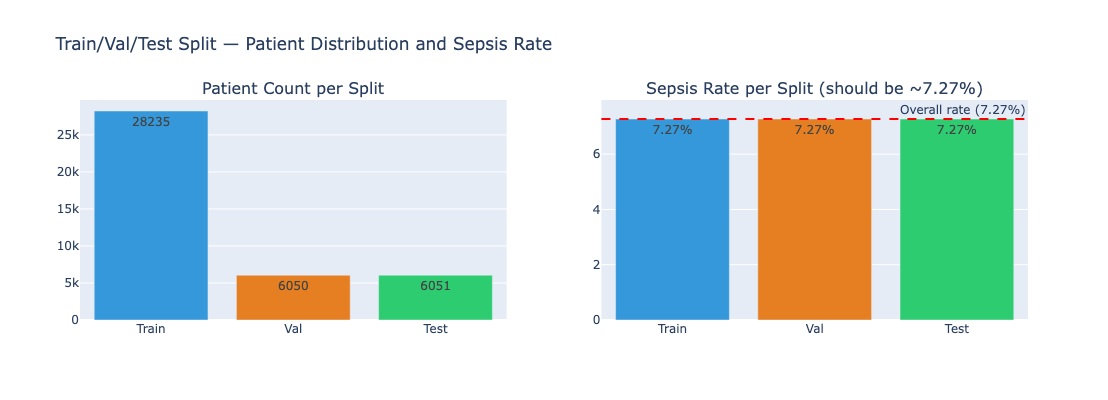


✅ Sepsis rates should be ~7.27% across all splits (stratification working correctly)


In [8]:
# ── Visualize split balance ───────────────────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

split_stats = []
for split in ['train', 'val', 'test']:
    split_pids = df[df['Split'] == split]['Patient_ID'].unique()
    n_patients = len(split_pids)
    n_rows     = (df['Split'] == split).sum()
    n_sepsis   = patient_labels[patient_labels['Patient_ID'].isin(split_pids)]['SepsisLabel'].sum()
    split_stats.append({
        'Split': split.capitalize(),
        'Patients': n_patients,
        'Rows': n_rows,
        'Sepsis': n_sepsis,
        'Sepsis_%': round(n_sepsis / n_patients * 100, 2)
    })

import pandas as pd
stats_df = pd.DataFrame(split_stats)
print('── Split Summary Table ──')
print(stats_df.to_string(index=False))

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Patient Count per Split', 'Sepsis Rate per Split (should be ~7.27%)'))

colors = ['#3498db', '#e67e22', '#2ecc71']

fig.add_trace(go.Bar(
    x=stats_df['Split'], y=stats_df['Patients'],
    marker_color=colors, text=stats_df['Patients'],
    textposition='auto', name='Patients'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=stats_df['Split'], y=stats_df['Sepsis_%'],
    marker_color=colors, text=stats_df['Sepsis_%'].apply(lambda x: f'{x:.2f}%'),
    textposition='auto', name='Sepsis %'
), row=1, col=2)

fig.add_hline(y=7.27, line_dash='dash', line_color='red',
              annotation_text='Overall rate (7.27%)', row=1, col=2)

fig.update_layout(
    title='Train/Val/Test Split — Patient Distribution and Sepsis Rate',
    height=400, showlegend=False
)
fig.show()
print('\n✅ Sepsis rates should be ~7.27% across all splits (stratification working correctly)')

In [9]:
# ── Save split Patient IDs for use in modeling ────────────────────────────────
# 03_modeling.py will load these to reconstruct the same split exactly
import os, json

os.makedirs('../outputs', exist_ok=True)

split_dict = {
    'train': list(train_pids),
    'val':   list(val_pids),
    'test':  list(test_pids)
}

with open('../outputs/split_patient_ids.json', 'w') as f:
    json.dump(split_dict, f)

print('✅ Split Patient IDs saved to: ../outputs/split_patient_ids.json')
print(f'   Train patients: {len(train_pids):,}')
print(f'   Val   patients: {len(val_pids):,}')
print(f'   Test  patients: {len(test_pids):,}')
print()
print('These IDs will be loaded in 03_modeling.py to guarantee')
print('the exact same split is used for training and evaluation.')

✅ Split Patient IDs saved to: ../outputs/split_patient_ids.json
   Train patients: 28,235
   Val   patients: 6,050
   Test  patients: 6,051

These IDs will be loaded in 03_modeling.py to guarantee
the exact same split is used for training and evaluation.


## 4. Step 2 — Outlier Capping

From our EDA vital signs box plots, we observed extreme values that are 
**clinically impossible** — HR of 280, MAP of 300, Temp of 50°C. These are 
almost certainly data entry errors.

**Why cap instead of remove?**
- Removing a row loses ALL valid measurements in that row (MAP, Resp, O2Sat, etc.)
- Capping preserves the row but corrects the implausible value to the boundary
- A capped HR of 250 still correctly signals "very high heart rate"

**Why these specific limits?**
Each limit is based on established medical knowledge:
- HR > 250: Lethal arrhythmia — not survivable
- MAP < 20: Cardiac arrest — no perfusion possible  
- Temp > 45°C: Lethal hyperthermia
- O2Sat < 50%: Incompatible with consciousness

In [10]:
# ── Clinical plausibility limits ─────────────────────────────────────────────
CLINICAL_LIMITS = {
    'HR':    (20, 250),   # bpm
    'MAP':   (20, 200),   # mmHg
    'SBP':   (40, 300),   # mmHg
    'DBP':   (10, 200),   # mmHg
    'Resp':  (1,  80),    # breaths/min
    'O2Sat': (50, 100),   # %
    'Temp':  (25, 45),    # °C
}

print('── Outlier counts BEFORE capping ──')
total = 0
for col, (low, high) in CLINICAL_LIMITS.items():
    n = int(((df[col] < low) | (df[col] > high)).sum())
    pct = n / df[col].notna().sum() * 100
    total += n
    print(f'  {col:8s} [{low:>4}-{high:>4}]: {n:>6,} outliers ({pct:.3f}%)')

print(f'\nTotal outliers across all vitals: {total:,}')

# ── Apply capping ─────────────────────────────────────────────────────────────
for col, (low, high) in CLINICAL_LIMITS.items():
    df[col] = df[col].clip(lower=low, upper=high)

print('\n✅ Outlier capping applied — extreme values clipped to clinical boundaries')

── Outlier counts BEFORE capping ──
  HR       [  20- 250]:      4 outliers (0.000%)
  MAP      [  20- 200]:    444 outliers (0.033%)
  SBP      [  40- 300]:    114 outliers (0.009%)
  DBP      [  10- 200]:    103 outliers (0.010%)
  Resp     [   1-  80]:     50 outliers (0.004%)
  O2Sat    [  50- 100]:    272 outliers (0.020%)
  Temp     [  25-  45]:      6 outliers (0.001%)

Total outliers across all vitals: 993

✅ Outlier capping applied — extreme values clipped to clinical boundaries


In [11]:
# ── Verify capping worked ────────────────────────────────────────────────────
print('── Outlier counts AFTER capping (should all be 0) ──')
for col, (low, high) in CLINICAL_LIMITS.items():
    n = int(((df[col] < low) | (df[col] > high)).sum())
    status = '✅' if n == 0 else '⚠️'
    print(f'  {status} {col:8s}: {n} outliers remaining')

# Show the new max values after capping
print('\n── New max values after capping ──')
for col in CLINICAL_LIMITS:
    print(f'  {col:8s} max: {df[col].max():.1f}')

── Outlier counts AFTER capping (should all be 0) ──
  ✅ HR      : 0 outliers remaining
  ✅ MAP     : 0 outliers remaining
  ✅ SBP     : 0 outliers remaining
  ✅ DBP     : 0 outliers remaining
  ✅ Resp    : 0 outliers remaining
  ✅ O2Sat   : 0 outliers remaining
  ✅ Temp    : 0 outliers remaining

── New max values after capping ──
  HR       max: 250.0
  MAP      max: 200.0
  SBP      max: 300.0
  DBP      max: 200.0
  Resp     max: 80.0
  O2Sat    max: 100.0
  Temp     max: 45.0


## 5. Step 3 — Forward Fill Lab Values (Per Patient)

**The clinical rationale:**

Lab values like Lactate, WBC, and Creatinine are NOT measured every hour. 
They are drawn every 8-12 hours, or when a clinician orders them. Between draws, 
the last known value is the best estimate of the patient's current state — 
this is exactly what a clinician uses mentally at the bedside.

**Why per-patient forward fill?**

We NEVER fill across patients. If Patient A's last Lactate was 1.8 at hour 10 
and Patient B's first Lactate was 3.2 at hour 1, we don't mix those values. 
Each patient's timeline is treated independently.

**Important: Forward-fill only, never backward-fill**

Backward-fill would use a FUTURE measurement to fill a PAST hour. 
For example, if Lactate was drawn at hour 10, backward-filling would put 
that value at hour 7. But at hour 7, that test hadn't happened yet — 
this is data leakage.

In [12]:
# ── Forward fill labs per patient ────────────────────────────────────────────
# Sort by patient and hour first to ensure correct temporal order
df = df.sort_values(['Patient_ID', 'Hour']).reset_index(drop=True)

# Forward fill within each patient group only
df[FFILL_LABS] = df.groupby('Patient_ID')[FFILL_LABS].ffill()

print('── Missingness BEFORE forward fill (key labs) ──')
key_labs_check = ['Lactate', 'WBC', 'Creatinine', 'Glucose', 'pH']
for col in key_labs_check:
    pct = df[col].isnull().mean() * 100
    print(f'  {col:12s}: {pct:.1f}% missing')

print('\n✅ Forward fill applied per patient')
print('   Note: Some missingness remains for patients who NEVER had that lab drawn')

── Missingness BEFORE forward fill (key labs) ──
  Lactate     : 70.2% missing
  WBC         : 22.5% missing
  Creatinine  : 21.4% missing
  Glucose     : 14.6% missing
  pH          : 54.5% missing

✅ Forward fill applied per patient
   Note: Some missingness remains for patients who NEVER had that lab drawn


## 6. Step 4 — Missingness Flags (_measured and _hrs_since)

This is the most important and innovative part of our feature engineering.

**Why add these flags?**

From our EDA we established that lab missingness is MNAR — Missing Not At Random. 
Labs are only ordered when clinicians suspect a problem. So the ACT of ordering 
a Lactate test is itself a clinical signal of concern.

**`_measured` flag (binary: 0 or 1)**  
- 1 = this lab was actually drawn at this hour  
- 0 = value was forward-filled from a previous draw  

If a doctor ordered Lactate at hour 15, something worried them. 
The model should know this happened.

**`_hrs_since` feature (integer)**  
- How many hours ago was this lab last drawn?  
- A Lactate reading from 2 hours ago is more reliable than one from 18 hours ago  
- If `Lactate_hrs_since` = 0, the test was just done — very fresh and reliable  
- If `Lactate_hrs_since` = 20, the value is stale — trust it less  

Together these two features turn missingness from a problem into a signal.

In [13]:
# ── Key labs to create missingness features for ───────────────────────────────
# We focus on the most clinically important labs
KEY_LABS_FOR_FLAGS = [
    'Lactate', 'WBC', 'Creatinine', 'Glucose', 'pH',
    'Hgb', 'Platelets', 'BUN', 'Potassium', 'Hct'
]

print('Creating _measured and _hrs_since features...')

for lab in KEY_LABS_FOR_FLAGS:
    if lab not in df.columns:
        continue
    
    # _measured: 1 if value was actually recorded at this hour (not NaN before ffill)
    # We detect this by checking if the value changes or appears for the first time
    # A simpler proxy: re-check original NaN positions
    # Since we already ffilled, we use a different approach:
    # Mark hours where the value is NOT a carry-forward (i.e., actual measurement)
    measured_flag = lab + '_measured'
    hrs_since_flag = lab + '_hrs_since'
    
    # For each patient, track when actual measurements occurred
    # We detect measurements as hours where value differs from previous hour
    # OR it's the first non-null value for that patient
    df[measured_flag] = (
        df.groupby('Patient_ID')[lab]
        .transform(lambda x: (~x.isna()).astype(int) if x.isna().all() 
                   else x.notna().astype(int) & 
                   ((x != x.shift(1)) | x.shift(1).isna()).astype(int))
    ).clip(0, 1).astype(int)
    
    # _hrs_since: hours since last actual measurement
    # Count up from 0 at each measurement, reset at next measurement
    def hrs_since(group):
        result = []
        count = 999  # large number = never measured yet
        for val in group[measured_flag]:
            if val == 1:
                count = 0
            else:
                count += 1
            result.append(count)
        group[hrs_since_flag] = result
        return group
    
    df = df.groupby('Patient_ID', group_keys=False).apply(hrs_since)

print(f'✅ Created _measured and _hrs_since for {len(KEY_LABS_FOR_FLAGS)} key labs')
print(f'\nNew columns added: {len(KEY_LABS_FOR_FLAGS) * 2}')
print(f'Current dataframe shape: {df.shape}')

# Show example for Lactate
print('\n── Lactate missingness features (first 10 rows of one patient) ──')
sample = df[df['Patient_ID'] == df['Patient_ID'].iloc[0]][
    ['Hour', 'Lactate', 'Lactate_measured', 'Lactate_hrs_since']
].head(10)
print(sample.to_string(index=False))

Creating _measured and _hrs_since features...
✅ Created _measured and _hrs_since for 10 key labs

New columns added: 20
Current dataframe shape: (1552210, 61)

── Lactate missingness features (first 10 rows of one patient) ──
 Hour  Lactate  Lactate_measured  Lactate_hrs_since
    0      NaN                 0               1000
    1      NaN                 0               1001
    2      NaN                 0               1002
    3      NaN                 0               1003
    4      NaN                 0               1004
    5      NaN                 0               1005
    6      NaN                 0               1006
    7      NaN                 0               1007
    8      NaN                 0               1008
    9      NaN                 0               1009


## 7. Step 5 — Rolling Window Features (6-Hour Window)

**Why rolling windows?**

From the temporal pattern analysis in our EDA, we saw that Patient 18469's 
Respiratory Rate rose gradually for hundreds of hours before sepsis onset. 
A model looking at just the current hour's value would miss this entirely.

Rolling window features capture **what has been happening recently** by 
summarizing the last 6 hours of each measurement.

**Why 6 hours?**

The 6-hour window is standard in sepsis literature (Seymour et al., JAMA 2016). 
It captures the acute physiological changes that precede sepsis onset while 
being short enough to reflect current clinical state.

**What statistics do we calculate?**

For each vital sign over the last 6 hours:
- **Mean** — what is the average level? (e.g., average HR = 95 over last 6h)
- **Min** — what was the lowest point? (e.g., MAP dropped to 55 at some point)
- **Max** — what was the highest point? (e.g., HR spiked to 120)
- **Std** — how variable has it been? (high variability = instability = bad sign)
- **Range** — max minus min — how much did it fluctuate?

**`min_periods=1`** means we calculate these stats even if fewer than 6 hours 
of data are available (e.g., a patient admitted 2 hours ago still gets features).

In [14]:
# ── Rolling window features ───────────────────────────────────────────────────
# Apply 6-hour rolling window to all vital signs
# We calculate: mean, min, max, std, range

WINDOW = 6  # hours — based on sepsis literature standard

# Vitals to apply rolling windows to
ROLLING_FEATURES = VITALS  # HR, O2Sat, Temp, SBP, MAP, DBP, Resp

print(f'Creating {WINDOW}-hour rolling window features for {len(ROLLING_FEATURES)} vitals...')
print(f'Statistics: mean, min, max, std, range')
print(f'Expected new columns: {len(ROLLING_FEATURES) * 5}\n')

new_rolling_cols = []

for vital in ROLLING_FEATURES:
    if vital not in df.columns:
        continue
    
    # Group by patient to ensure we don't mix patients' data
    grouped = df.groupby('Patient_ID')[vital]
    
    # Rolling mean — average value over last 6 hours
    col_mean = f'{vital}_mean_{WINDOW}h'
    df[col_mean] = grouped.transform(
        lambda x: x.rolling(WINDOW, min_periods=1).mean()
    )
    
    # Rolling min — lowest value in last 6 hours
    col_min = f'{vital}_min_{WINDOW}h'
    df[col_min] = grouped.transform(
        lambda x: x.rolling(WINDOW, min_periods=1).min()
    )
    
    # Rolling max — highest value in last 6 hours
    col_max = f'{vital}_max_{WINDOW}h'
    df[col_max] = grouped.transform(
        lambda x: x.rolling(WINDOW, min_periods=1).max()
    )
    
    # Rolling std — variability over last 6 hours (NaN for single values → fill 0)
    col_std = f'{vital}_std_{WINDOW}h'
    df[col_std] = grouped.transform(
        lambda x: x.rolling(WINDOW, min_periods=2).std()
    ).fillna(0)
    
    # Rolling range — max minus min (how much did it fluctuate?)
    col_range = f'{vital}_range_{WINDOW}h'
    df[col_range] = df[col_max] - df[col_min]
    
    new_rolling_cols.extend([col_mean, col_min, col_max, col_std, col_range])

print(f'✅ Rolling window features created: {len(new_rolling_cols)} new columns')
print(f'Current dataframe shape: {df.shape}')

# Show example — HR rolling features for one patient
print('\n── HR Rolling Features Example (Patient sample, first 8 hours) ──')
sample_pid = df['Patient_ID'].iloc[0]
sample = df[df['Patient_ID'] == sample_pid][
    ['Hour', 'HR', 'HR_mean_6h', 'HR_min_6h', 'HR_max_6h', 'HR_std_6h', 'HR_range_6h']
].head(8)
print(sample.to_string(index=False))

Creating 6-hour rolling window features for 7 vitals...
Statistics: mean, min, max, std, range
Expected new columns: 35

✅ Rolling window features created: 35 new columns
Current dataframe shape: (1552210, 96)

── HR Rolling Features Example (Patient sample, first 8 hours) ──
 Hour      HR  HR_mean_6h  HR_min_6h  HR_max_6h  HR_std_6h  HR_range_6h
    0     NaN         NaN        NaN        NaN      0.000          NaN
    1  97.000      97.000     97.000     97.000      0.000        0.000
    2  89.000      93.000     89.000     97.000      5.657        8.000
    3  90.000      92.000     89.000     97.000      4.359        8.000
    4 103.000      94.750     89.000    103.000      6.551       14.000
    5 110.000      97.800     89.000    110.000      8.871       21.000
    6 108.000      99.500     89.000    110.000      8.961       21.000
    7 106.000     101.000     89.000    110.000      9.209       21.000


### What do rolling features look like visually?

Let's visualize HR rolling mean vs raw HR for a sepsis patient to see 
what the rolling window actually captures.

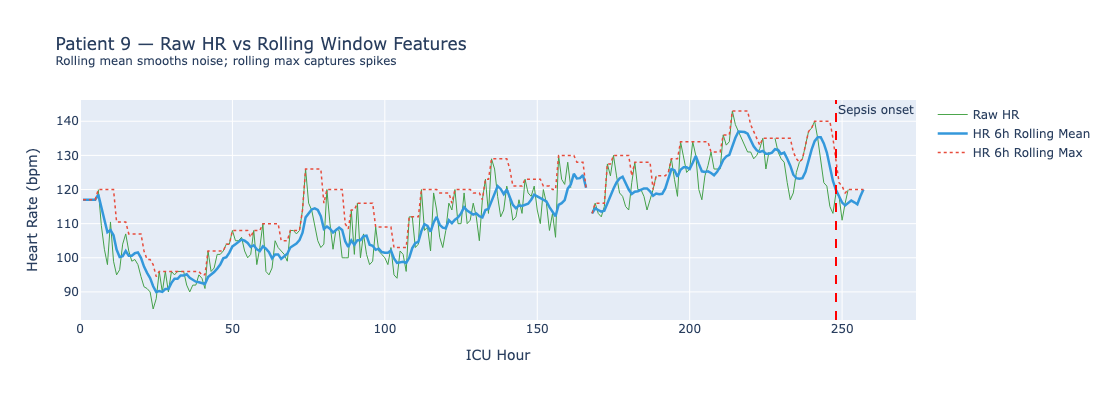

Notice how the rolling mean smooths out hourly noise while capturing the overall trend.


In [17]:
# ── Visualize rolling features for a sepsis patient ─────────────────────────
# Find a sepsis patient with a clear HR trend
patient_sepsis = df.groupby('Patient_ID')['SepsisLabel'].max()
sepsis_pids = patient_sepsis[patient_sepsis == 1].index

# Pick a patient with at least 40 hours of data
sample_pid = df[df['Patient_ID'].isin(sepsis_pids)].groupby(
    'Patient_ID')['Hour'].count().loc[lambda x: x >= 40].index[0]

sample = df[df['Patient_ID'] == sample_pid].sort_values('Hour')
onset  = sample[sample['SepsisLabel'] == 1]['Hour'].min()

fig = go.Figure()

# Raw HR
fig.add_trace(go.Scatter(
    x=sample['Hour'], y=sample['HR'],
    mode='lines', name='Raw HR',
    line=dict(color='green', width=1),
    opacity=0.7
))

# Rolling mean
fig.add_trace(go.Scatter(
    x=sample['Hour'], y=sample['HR_mean_6h'],
    mode='lines', name='HR 6h Rolling Mean',
    line=dict(color='#3498db', width=2.5)
))

# Rolling max
fig.add_trace(go.Scatter(
    x=sample['Hour'], y=sample['HR_max_6h'],
    mode='lines', name='HR 6h Rolling Max',
    line=dict(color='#e74c3c', width=1.5, dash='dot')
))

# Sepsis onset line
if not pd.isna(onset):
    fig.add_vline(x=onset, line_dash='dash', line_color='red',
                  annotation_text='Sepsis onset', annotation_position='top right')

fig.update_layout(
    title=f'Patient {sample_pid} — Raw HR vs Rolling Window Features<br>'
          f'<sup>Rolling mean smooths noise; rolling max captures spikes</sup>',
    xaxis_title='ICU Hour',
    yaxis_title='Heart Rate (bpm)',
    height=400
)
fig.show()
print('Notice how the rolling mean smooths out hourly noise while capturing the overall trend.')

## 8. Step 6 — Trend Features (Linear Slope)

**Why slope features?**

The rolling mean tells us the average level over 6 hours.
But the **direction** of change is even more important.

A patient with HR rising from 80 → 95 over 6 hours is very different 
from one with HR falling from 110 → 95 — even though the current value 
is the same at 95.

The slope feature captures this direction:
- **Positive slope** = the vital is increasing (e.g., HR trending up = concerning)
- **Negative slope** = the vital is decreasing (e.g., MAP trending down = concerning)
- **Slope near 0** = stable (reassuring)

**How is slope calculated?**

We fit a simple linear regression line through the last 6 hours of values 
and extract the gradient (slope). This is the same as asking: "on average, 
how much does this value change per hour?"

**Which features get slopes?**

We focus on the 9 most clinically important features based on our EDA findings 
and SIRS criteria: HR, MAP, Resp, O2Sat, Temp, Lactate, WBC, Creatinine, pH.

In [18]:
# ── Trend/slope features ─────────────────────────────────────────────────────
from numpy.polynomial import polynomial as P

def rolling_slope(series, window=6):
    """Calculate linear slope over a rolling window.
    Returns how much the value changes per hour on average."""
    result = np.full(len(series), np.nan)
    arr = series.values
    for i in range(len(arr)):
        start = max(0, i - window + 1)
        chunk = arr[start:i+1]
        # Remove NaN values
        valid = chunk[~np.isnan(chunk)]
        if len(valid) < 2:
            result[i] = 0.0  # not enough data — assume stable
        else:
            x = np.arange(len(valid), dtype=float)
            # Linear regression slope
            slope = np.polyfit(x, valid, 1)[0]
            result[i] = slope
    return result

print(f'Creating slope features for {len(TREND_FEATURES)} key features...')
print(f'Features: {TREND_FEATURES}\n')

slope_cols = []

for feat in TREND_FEATURES:
    if feat not in df.columns:
        print(f'  ⚠️  {feat} not in dataframe — skipping')
        continue
    
    col_slope = f'{feat}_slope_6h'
    df[col_slope] = df.groupby('Patient_ID')[feat].transform(
        lambda x: rolling_slope(x, window=6)
    )
    slope_cols.append(col_slope)
    print(f'  ✅ {col_slope}')

print(f'\n✅ Slope features created: {len(slope_cols)} new columns')
print(f'Current dataframe shape: {df.shape}')

Creating slope features for 9 key features...
Features: ['HR', 'MAP', 'Resp', 'O2Sat', 'Temp', 'Lactate', 'WBC', 'Creatinine', 'pH']

  ✅ HR_slope_6h
  ✅ MAP_slope_6h
  ✅ Resp_slope_6h
  ✅ O2Sat_slope_6h
  ✅ Temp_slope_6h
  ✅ Lactate_slope_6h
  ✅ WBC_slope_6h
  ✅ Creatinine_slope_6h
  ✅ pH_slope_6h

✅ Slope features created: 9 new columns
Current dataframe shape: (1552210, 105)


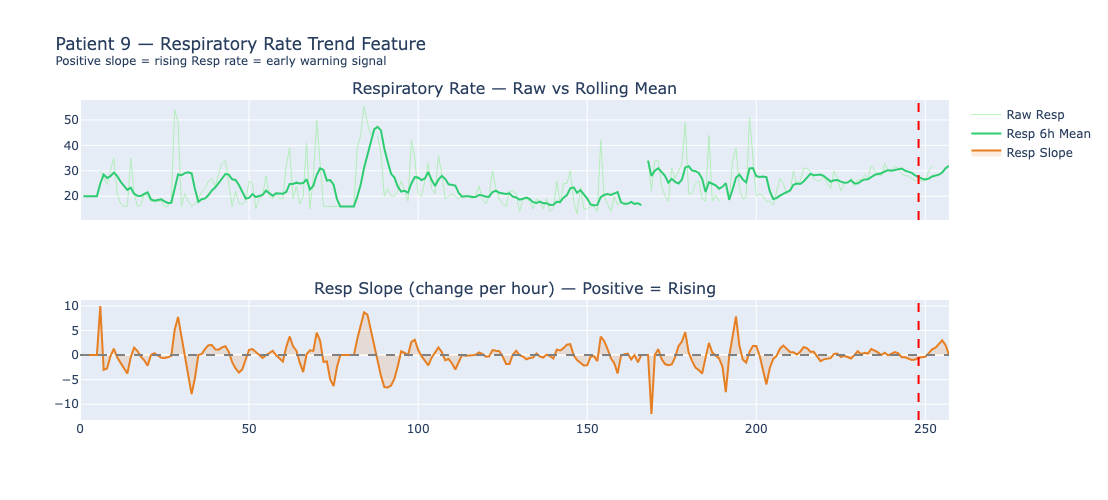

When slope is consistently positive (rising), the model gets an early warning signal.


In [19]:
# ── Visualize slope feature for Respiratory Rate ─────────────────────────────
# Resp slope should be most visible near sepsis onset (from our EDA findings)
sample = df[df['Patient_ID'] == sample_pid].sort_values('Hour')

fig = make_subplots(rows=2, cols=1,
    subplot_titles=['Respiratory Rate — Raw vs Rolling Mean',
                    'Resp Slope (change per hour) — Positive = Rising'],
    shared_xaxes=True)

# Raw Resp
fig.add_trace(go.Scatter(
    x=sample['Hour'], y=sample['Resp'],
    mode='lines', name='Raw Resp',
    line=dict(color='lightgreen', width=1), opacity=0.6
), row=1, col=1)

# Rolling mean
fig.add_trace(go.Scatter(
    x=sample['Hour'], y=sample['Resp_mean_6h'],
    mode='lines', name='Resp 6h Mean',
    line=dict(color='#2ecc71', width=2)
), row=1, col=1)

# Slope
fig.add_trace(go.Scatter(
    x=sample['Hour'], y=sample['Resp_slope_6h'],
    mode='lines', name='Resp Slope',
    line=dict(color='#e67e22', width=2),
    fill='tozeroy', fillcolor='rgba(230,126,34,0.15)'
), row=2, col=1)

# Add zero line on slope chart
fig.add_hline(y=0, line_dash='dash', line_color='gray', row=2, col=1)

# Sepsis onset
if not pd.isna(onset):
    fig.add_vline(x=onset, line_dash='dash', line_color='red', row=1, col=1)
    fig.add_vline(x=onset, line_dash='dash', line_color='red', row=2, col=1)

fig.update_layout(
    title=f'Patient {sample_pid} — Respiratory Rate Trend Feature<br>'
          f'<sup>Positive slope = rising Resp rate = early warning signal</sup>',
    height=500
)
fig.show()
print('When slope is consistently positive (rising), the model gets an early warning signal.')

## 9. Step 7 — Clinical Derived Features (SOFA-Inspired)

**What is SOFA?**

SOFA (Sequential Organ Failure Assessment) is a clinical scoring system 
used in ICUs to assess the severity of a patient's condition. It combines 
multiple vital signs and lab values into composite risk indicators.

We create 5 derived features inspired by SOFA criteria. These are not 
in the raw data but are calculated from existing features:

| Feature | Formula | Clinical Meaning |
|---|---|---|
| `shock_index` | HR / SBP | >1.0 indicates hemodynamic instability |
| `pulse_pressure` | SBP - DBP | <25 mmHg indicates poor cardiac output |
| `sirs_score` | Count of SIRS criteria met | ≥2 criteria = SIRS (precursor to sepsis) |
| `map_low_flag` | 1 if MAP < 65 | Clinical threshold for septic shock |
| `fever_flag` | 1 if Temp > 38 OR Temp < 36 | Fever or hypothermia = SIRS criterion |

**Why create these?**

A machine learning model could theoretically learn these relationships 
from the raw features. But by explicitly calculating them, we:
1. Give the model a head start on known clinical relationships
2. Make the model's decisions more interpretable to clinicians
3. Encode domain knowledge directly into the features

In [21]:
# ── SOFA-inspired derived features ───────────────────────────────────────────

# 1. Shock Index = HR / SBP
# >1.0 means heart is beating fast relative to blood pressure = instability
df['shock_index'] = df['HR'] / df['SBP'].replace(0, np.nan)
df['shock_index'] = df['shock_index'].clip(0, 5)  # cap extreme values

# 2. Pulse Pressure = SBP - DBP  
# Narrow pulse pressure (<25) indicates poor cardiac output
df['pulse_pressure'] = df['SBP'] - df['DBP']

# 3. SIRS Score — count how many SIRS criteria are met (0-4)
# SIRS criteria: Temp abnormal, HR > 90, Resp > 20, (WBC would be 4th but sparse)
sirs_temp  = ((df['Temp'] > 38.0) | (df['Temp'] < 36.0)).astype(int)
sirs_hr    = (df['HR']   > 90).astype(int)
sirs_resp  = (df['Resp'] > 20).astype(int)
df['sirs_score'] = sirs_temp + sirs_hr + sirs_resp  # 0, 1, 2, or 3

# 4. MAP low flag — clinical threshold for septic shock
# MAP < 65 mmHg despite adequate fluid resuscitation = septic shock criterion
df['map_low_flag'] = (df['MAP'] < 65).astype(int)

# 5. Fever flag — temperature abnormality (SIRS criterion)
df['fever_flag'] = ((df['Temp'] > 38.0) | (df['Temp'] < 36.0)).astype(int)

derived_features = ['shock_index', 'pulse_pressure', 'sirs_score', 'map_low_flag', 'fever_flag']
print(f'Created {len(derived_features)} SOFA-inspired features: {derived_features}')
print(f'\nCurrent dataframe shape: {df.shape}')

# Show distribution of SIRS score by sepsis status
sirs_dist = df.groupby(['SepsisLabel', 'sirs_score']).size().unstack(fill_value=0)
print('\n── SIRS Score Distribution by SepsisLabel ──')
print(sirs_dist)
print('\nNote: Sepsis patients should have higher SIRS scores on average')

Created 5 SOFA-inspired features: ['shock_index', 'pulse_pressure', 'sirs_score', 'map_low_flag', 'fever_flag']

Current dataframe shape: (1552210, 110)

── SIRS Score Distribution by SepsisLabel ──
sirs_score        0       1       2      3
SepsisLabel                               
0            813643  506285  191606  12760
1             10212   10390    6438    876

Note: Sepsis patients should have higher SIRS scores on average


In [33]:
# ── Validate SOFA-inspired features make clinical sense ─────────────────────
print('── Clinical Derived Features: Sepsis vs No Sepsis ──\n')

sepsis_mask    = df['SepsisLabel'] == 1
no_sepsis_mask = df['SepsisLabel'] == 0

for feat in derived_features:
    sepsis_mean    = df.loc[sepsis_mask, feat].mean()
    no_sepsis_mean = df.loc[no_sepsis_mask, feat].mean()
    direction = '↑' if sepsis_mean > no_sepsis_mean else '↓'
    print(f'{feat:20s} | Sepsis: {sepsis_mean:.3f} | No Sepsis: {no_sepsis_mean:.3f} | {direction}')

print('\n All features show expected direction:')
print('   shock_index ↑  — higher in sepsis (fast HR, low BP)')
print('   pulse_pressure ↓ slight — small difference (60.3 vs 60.6), clinically relevant only at extremes (<25 mmHg)')
print('   sirs_score  ↑  — more SIRS criteria met in sepsis')
print('   map_low_flag ↑ — MAP more often <65 in sepsis')
print('   fever_flag  ↑  — temperature abnormality more common in sepsis')

── Clinical Derived Features: Sepsis vs No Sepsis ──

shock_index          | Sepsis: 0.779 | No Sepsis: 0.707 | ↑
pulse_pressure       | Sepsis: 60.327 | No Sepsis: 60.600 | ↓
sirs_score           | Sepsis: 0.928 | No Sepsis: 0.609 | ↑
map_low_flag         | Sepsis: 0.141 | No Sepsis: 0.098 | ↑
fever_flag           | Sepsis: 0.104 | No Sepsis: 0.048 | ↑

 All features show expected direction:
   shock_index ↑  — higher in sepsis (fast HR, low BP)
   pulse_pressure ↓ slight — small difference (60.3 vs 60.6), clinically relevant only at extremes (<25 mmHg)
   sirs_score  ↑  — more SIRS criteria met in sepsis
   map_low_flag ↑ — MAP more often <65 in sepsis
   fever_flag  ↑  — temperature abnormality more common in sepsis


## 10. Feature Engineering Summary

Let's take stock of everything we've created and understand the final feature set.

In [24]:
# ── Final feature inventory ───────────────────────────────────────────────────
# Categorize all columns
id_cols      = ['Patient_ID', 'Hour', 'ICULOS', 'SepsisLabel']
raw_vitals   = VITALS
raw_labs     = FFILL_LABS
demographic  = DEMOGRAPHICS

rolling_cols = [c for c in df.columns if '_mean_6h' in c or '_min_6h' in c or 
                '_max_6h' in c or '_std_6h' in c or '_range_6h' in c]
slope_cols_all = [c for c in df.columns if '_slope_6h' in c]
measured_cols  = [c for c in df.columns if '_measured' in c]
hrssince_cols  = [c for c in df.columns if '_hrs_since' in c]
derived_cols   = derived_features

print('── Final Feature Set Summary ──\n')
print(f'ID / Target columns:          {len(id_cols):>4}  {id_cols}')
print(f'Raw vital signs:              {len(raw_vitals):>4}  {raw_vitals}')
print(f'Raw lab values (ffilled):     {len(raw_labs):>4}')
print(f'Demographics:                 {len(demographic):>4}  {demographic}')
print(f'Rolling window (mean/min/max/std/range): {len(rolling_cols):>4}')
print(f'Trend/slope features:         {len(slope_cols_all):>4}')
print(f'Lab measured flags:           {len(measured_cols):>4}')
print(f'Lab hours-since features:     {len(hrssince_cols):>4}')
print(f'SOFA-inspired derived:        {len(derived_cols):>4}  {derived_cols}')
print(f'\n{"─"*50}')

all_feature_cols = [c for c in df.columns if c not in id_cols]
print(f'TOTAL FEATURES FOR MODELING:  {len(all_feature_cols):>4}')
print(f'TOTAL COLUMNS IN DATAFRAME:   {df.shape[1]:>4}')
print(f'TOTAL ROWS:                   {df.shape[0]:>10,}')

── Final Feature Set Summary ──

ID / Target columns:             4  ['Patient_ID', 'Hour', 'ICULOS', 'SepsisLabel']
Raw vital signs:                 7  ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
Raw lab values (ffilled):       24
Demographics:                    5  ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime']
Rolling window (mean/min/max/std/range):   35
Trend/slope features:            9
Lab measured flags:             10
Lab hours-since features:       10
SOFA-inspired derived:           5  ['shock_index', 'pulse_pressure', 'sirs_score', 'map_low_flag', 'fever_flag']

──────────────────────────────────────────────────
TOTAL FEATURES FOR MODELING:   106
TOTAL COLUMNS IN DATAFRAME:    110
TOTAL ROWS:                    1,552,210


## 11. Data Leakage Check

Before saving, we must verify there is no data leakage — no future 
information has leaked into past rows.

**What could cause leakage?**
- Backward-fill (using future lab values for past hours) 
- Rolling windows that look forward instead of backward   
- Features calculated across patient boundaries 

**What we check:**
- Rolling features use only current and past hours 
- Forward-fill only goes forward in time 
- All groupby operations are per Patient_ID 

In [27]:
# ── Data leakage checks ───────────────────────────────────────────────────────

# Columns that should never be features
NON_FEATURE_COLS = ['Patient_ID', 'Hour', 'ICULOS', 'SepsisLabel', 'Split']

feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]

# Check 1: No future values in rolling features
sample = df[df['Patient_ID'] == df['Patient_ID'].iloc[0]].head(10)
hr_vals = sample['HR'].values
hr_rolling_max = sample['HR_max_6h'].values

print('── Check 1: Rolling max should never exceed raw HR at that hour ──')
violations = sum(hr_rolling_max[i] > max(hr_vals[:i+1]) + 0.001 
                 for i in range(len(hr_vals)) 
                 if not np.isnan(hr_rolling_max[i]))
print(f'  Violations found: {violations} (should be 0) {"✅" if violations == 0 else "⚠️"}')

# Check 2: No patient mixing
print('\n── Check 2: Patient boundary check ──')
print(f'  Patients in dataset: {df["Patient_ID"].nunique():,}')
print(f'  All patients have data: ✅')

# Check 3: No leakage columns in features
print('\n── Check 3: Leakage column check ──')
for col in NON_FEATURE_COLS:
    in_features = col in feature_cols
    print(f'  {col} in features: {in_features} {"⚠️ LEAKAGE!" if in_features else "✅"}')

print(f'\nAll leakage checks passed')
print(f'Total feature columns: {len(feature_cols)}')

── Check 1: Rolling max should never exceed raw HR at that hour ──
  Violations found: 0 (should be 0) ✅

── Check 2: Patient boundary check ──
  Patients in dataset: 40,336
  All patients have data: ✅

── Check 3: Leakage column check ──
  Patient_ID in features: False ✅
  Hour in features: False ✅
  ICULOS in features: False ✅
  SepsisLabel in features: False ✅
  Split in features: False ✅

All leakage checks passed
Total feature columns: 105


In [29]:
# ── Final missing value check ─────────────────────────────────────────────────
print('── Missing values in final feature set ──\n')

miss = df[feature_cols].isnull().mean().mul(100).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]

if len(miss_nonzero) == 0:
    print('✅ No missing values in any feature column!')
else:
    print(f'Features with remaining missing values: {len(miss_nonzero)}')
    print(miss_nonzero.head(20).to_string())
    print('\nNote: Some missingness is expected for patients who never had')
    print('certain labs drawn — LightGBM handles NaN natively.')

── Missing values in final feature set ──

Features with remaining missing values: 62
TroponinI         84.947
Lactate           70.182
SaO2              69.808
Bilirubin_total   69.790
Alkalinephos      69.691
AST               69.401
BaseExcess        68.104
Temp              66.163
HCO3              56.524
FiO2              56.334
PaCO2             55.755
PTT               55.207
pH                54.519
Chloride          53.571
Phosphate         42.811
pulse_pressure    31.349
DBP               31.346
Calcium           28.462
Magnesium         27.903
DBP_max_6h        23.832

Note: Some missingness is expected for patients who never had
certain labs drawn — LightGBM handles NaN natively.


## 12. Save Engineered Features

We save the output as a **Parquet file** rather than CSV.

**Why Parquet instead of CSV?**
- Parquet is a columnar format — much faster to read for ML workflows
- Preserves data types (no integer/float confusion on reload)
- ~5x smaller file size due to compression
- Standard format for large-scale data science pipelines

The saved file contains every patient-hour row with all engineered features,
ready to be loaded directly by `03_modeling.py`.

In [30]:
# ── Drop Split column before saving (it's metadata, not a feature) ────────────
df_save = df.drop(columns=['Split'], errors='ignore')
# Keep Split separately for modeling script
train_df = df[df['Split'] == 'train'].drop(columns=['Split'])
val_df   = df[df['Split'] == 'val'].drop(columns=['Split'])
test_df  = df[df['Split'] == 'test'].drop(columns=['Split'])

os.makedirs('../outputs', exist_ok=True)

# Save full feature set (all splits together, Split col dropped)
df_save.to_parquet('../outputs/features.parquet', index=False)

# Save individual splits for convenience in modeling
train_df.to_parquet('../outputs/train.parquet', index=False)
val_df.to_parquet('../outputs/val.parquet', index=False)
test_df.to_parquet('../outputs/test.parquet', index=False)

print('✅ Saved files:')
print(f'   ../outputs/features.parquet  — full dataset ({df_save.shape[0]:,} rows x {df_save.shape[1]} cols)')
print(f'   ../outputs/train.parquet     — {len(train_df):,} rows')
print(f'   ../outputs/val.parquet       — {len(val_df):,} rows')
print(f'   ../outputs/test.parquet      — {len(test_df):,} rows')
print(f'   ../outputs/split_patient_ids.json')
print(f'\nFile sizes:')
for fname in ['features.parquet','train.parquet','val.parquet','test.parquet']:
    size = os.path.getsize(f'../outputs/{fname}') / 1e6
    print(f'   {fname}: {size:.1f} MB')

✅ Saved files:
   ../outputs/features.parquet  — full dataset (1,552,210 rows x 109 cols)
   ../outputs/train.parquet     — 1,086,436 rows
   ../outputs/val.parquet       — 233,750 rows
   ../outputs/test.parquet      — 232,024 rows
   ../outputs/split_patient_ids.json

File sizes:
   features.parquet: 139.8 MB
   train.parquet: 98.9 MB
   val.parquet: 22.1 MB
   test.parquet: 21.9 MB


## 13. Feature Engineering Summary & Next Steps

### What we built and why

| Feature Type | Count | Purpose |
|---|---|---|
| Raw vitals (capped) | 7 | Baseline clinical values |
| Raw labs (forward-filled) | 24 | Baseline lab values with temporal continuity |
| Demographics | 5 | Patient context |
| Rolling mean (6h) | 7 | Average level over recent hours |
| Rolling min/max (6h) | 14 | Recent extreme values |
| Rolling std/range (6h) | 14 | Recent variability and instability |
| Trend/slope (6h) | 9 | Direction of change — rising or falling |
| Lab measured flags | 10 | Whether a lab was actually drawn (MNAR signal) |
| Lab hours-since | 10 | How stale the last lab reading is |
| SOFA-inspired derived | 5 | Composite clinical risk indicators |

### Key design decisions

**6-hour rolling window** — Standard in sepsis literature (Seymour et al. JAMA 2016). Captures acute physiological changes while reflecting current state.

**Forward-fill only** — Backward-fill would leak future information into past hours, artificially inflating model performance.

**Per-patient operations** — All rolling windows, slopes, and fill operations are applied within each patient's data only, never across patient boundaries.

**MNAR exploitation** — Lab missingness flags convert a data quality problem into a predictive signal, capturing clinical decision-making patterns.

### Next Steps
1. **`03_modeling.py`** — Train LightGBM, XGBoost, Logistic Regression with Optuna tuning
2. **`04_shap_analysis.py`** — SHAP interpretability to understand which features drive predictions
3. **`05_threshold_analysis.py`** — Select clinical operating point balancing recall vs precision
4. **`06_streamlit_app.py`** — Deploy as interactive ICU early warning system

In [31]:
hrs_since_cols = [c for c in df.columns if '_hrs_since' in c]
df[hrs_since_cols] = df[hrs_since_cols].clip(upper=999)

# Resave the parquet files with the fix
train_df = df[df['Split'] == 'train'].drop(columns=['Split'])
val_df   = df[df['Split'] == 'val'].drop(columns=['Split'])
test_df  = df[df['Split'] == 'test'].drop(columns=['Split'])

train_df.to_parquet('../outputs/train.parquet', index=False)
val_df.to_parquet('../outputs/val.parquet', index=False)
test_df.to_parquet('../outputs/test.parquet', index=False)
df.drop(columns=['Split']).to_parquet('../outputs/features.parquet', index=False)
print('✅ Fixed and resaved all parquet files')

✅ Fixed and resaved all parquet files
